# Exploración del laberinto

Validación previa al entrenamiento: cargar el laberinto desde el archivo del enunciado, visualizarlo, calcular el camino óptimo con BFS (referencia para evaluar al agente entrenado) y probar manualmente la API del ambiente.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

from maze import Maze, MazeEnv, ACTIONS, DELTAS

MAZE_PATH = '../data/project_lab_v2.txt'
maze = Maze.from_file(MAZE_PATH)
print(f'dimensiones      : {maze.nrows} filas x {maze.ncols} columnas = {maze.n_states()} celdas')
print(f'start, goal      : {maze.start} -> {maze.goal}')
print(f'segmentos archivo: {len(maze.wall_segments)} (incluye bordes)')
print(f'muros internos   : {len(maze.walls)} (los que efectivamente bloquean transiciones)')

dimensiones      : 8 filas x 7 columnas = 56 celdas
start, goal      : (6, 0) -> (1, 6)
segmentos archivo: 65 (incluye bordes)
muros internos   : 37 (los que efectivamente bloquean transiciones)


## Visualización del laberinto

Reproduce la figura de la imagen del enunciado: filas (X) verticales con 0 arriba, columnas (Y) horizontales. Punto rojo = start, punto azul = goal.

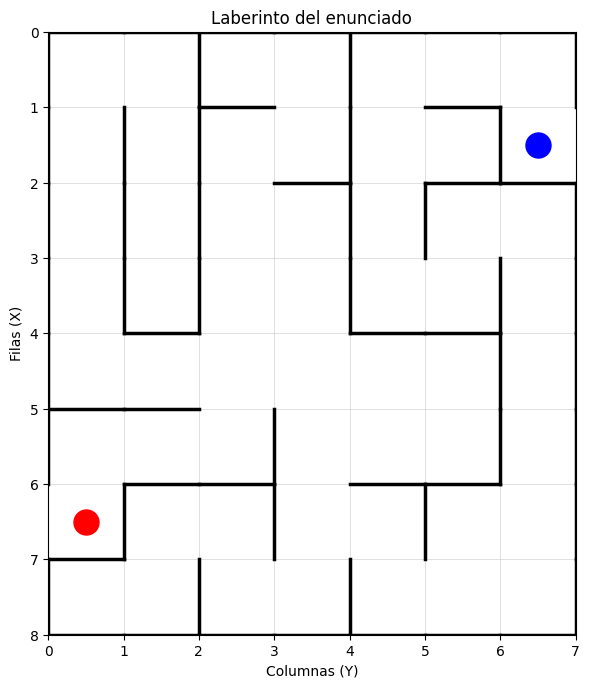

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 7))
maze.render(ax=ax, title='Laberinto del enunciado')
plt.tight_layout()
plt.show()

## Camino óptimo (BFS)

El laberinto es determinista y de talla pequeña: un BFS sobre el grafo de celdas accesibles entrega el número mínimo de pasos posible. Sirve como benchmark para evaluar al agente entrenado.

longitud óptima: 25 pasos
camino: [(6, 0), (5, 0), (5, 1), (5, 2), (4, 2), (4, 3), (5, 3), (6, 3), (6, 4), (7, 4), (7, 5), (6, 5), (6, 6), (5, 6), (4, 6), (3, 6), (2, 6), (2, 5), (3, 5), (3, 4), (2, 4), (1, 4), (0, 4), (0, 5), (0, 6), (1, 6)]


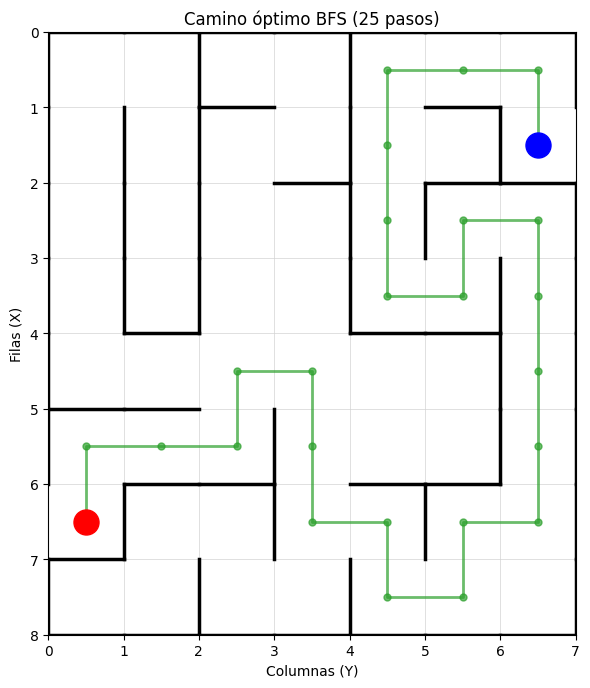

In [3]:
path = maze.shortest_path()
print(f'longitud óptima: {len(path) - 1} pasos')
print(f'camino: {path}')

fig, ax = plt.subplots(figsize=(6, 7))
maze.render(ax=ax, path=path, title=f'Camino óptimo BFS ({len(path)-1} pasos)')
plt.tight_layout()
plt.show()

## Prueba manual del ambiente

Verificamos transiciones, recompensa y manejo de choques siguiendo unas pocas acciones a mano.

In [4]:
env = MazeEnv(maze, max_steps=200)
state, _ = env.reset()
print(f'estado inicial: {state}\n')

# UP, UP (la primera UP es válida; la segunda choca contra muro y rebota)
for a in [0, 0, 3, 3, 1]:
    s, r, term, trunc, info = env.step(a)
    print(f'acción={ACTIONS[a]:<5} -> estado={s}  reward={r:+.0f}  '
          f'bumped={info["bumped"]}  term={term}')

estado inicial: (6, 0)

acción=UP    -> estado=(5, 0)  reward=-1  bumped=False  term=False
acción=UP    -> estado=(5, 0)  reward=-1  bumped=True  term=False
acción=RIGHT -> estado=(5, 1)  reward=-1  bumped=False  term=False
acción=RIGHT -> estado=(5, 2)  reward=-1  bumped=False  term=False
acción=DOWN  -> estado=(5, 2)  reward=-1  bumped=True  term=False


## Recorrer el camino BFS y verificar la recompensa total

Si nuestro env y el reward shaping son consistentes, recorrer el camino óptimo debe dar `(n_pasos - 1) * (-1) + 100`.

In [5]:
env.reset()
total = 0.0
for next_cell in path[1:]:
    cur = env.state
    delta = (next_cell[0] - cur[0], next_cell[1] - cur[1])
    action = next(k for k, v in DELTAS.items() if v == delta)
    _, r, term, _, _ = env.step(action)
    total += r
    if term:
        break
print(f'pasos = {env.steps}, recompensa total = {total}, terminated = {term}')
expected = (len(path) - 2) * (-1) + 100
print(f'esperado = {expected}  (24 pasos de costo -1 + transición final +100)')

pasos = 25, recompensa total = 76.0, terminated = True
esperado = 76  (24 pasos de costo -1 + transición final +100)
